<a href="https://colab.research.google.com/github/allatop/networks/blob/main/_3_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [ ]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pickle
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files
import os

!pip install streamlit -q
!npm install -g localtunnel &> /dev/null &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 129.9 MB/s eta 0:00:00


## 1.2. Разделяем данные на обучающую и тестовую выборку

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

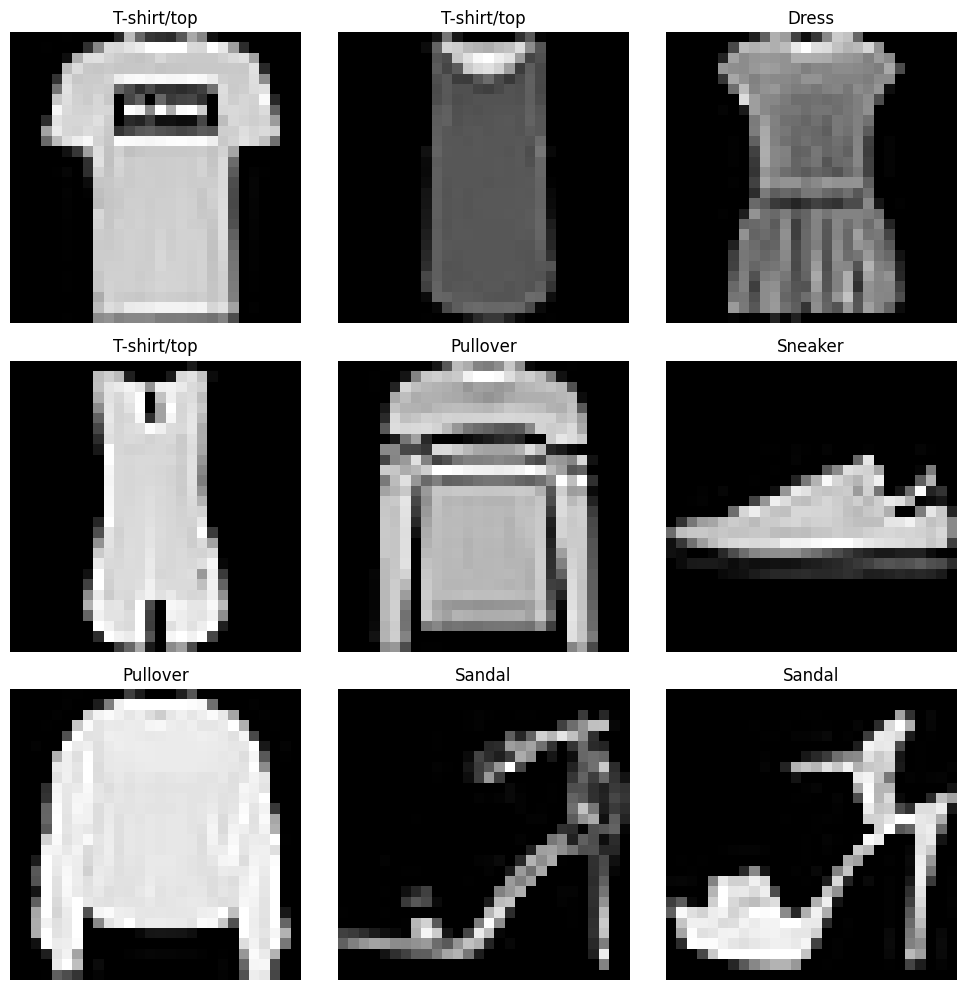

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))
    plt.title(class_names[trainy[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [ ]:
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

trainX_norm = trainX.astype('float32') / 255.0
testX_norm = testX.astype('float32') / 255.0

trainX_cnn = trainX_norm.reshape((trainX_norm.shape[0], 28, 28, 1))
testX_cnn = testX_norm.reshape((testX_norm.shape[0], 28, 28, 1))

trainY_cat = tf.keras.utils.to_categorical(trainy, 10)
testY_cat = tf.keras.utils.to_categorical(testy, 10)

model_task1_improved = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(0.001), input_shape=(28, 28, 1)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_task1_improved.summary()

model_task1_improved.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           25

 Total params: 297,386 (1.13 MB)

 Trainable params: 296,362 (1.13 MB)

 Non-trainable params: 1,024 (4.00 KB)

## 1.5. Обучаем модель

In [5]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model_task1_improved.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [early_stopping, checkpoint, reduce_lr]

history_task1_improved = model_task1_improved.fit(
    trainX_cnn, trainY_cat,
    validation_data=(testX_cnn, testY_cat),
    epochs=40,
    batch_size=64,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5542 - loss: 1.8950
Epoch 1: val_accuracy improved from None to 0.83220, saving model to best_model_task1_improved.keras

Epoch 1: finished saving model to best_model_task1_improved.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.6805 - loss: 1.4460 - val_accuracy: 0.8322 - val_loss: 0.9440 - learning_rate: 5.0000e-04
Epoch 2/40
936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8089 - loss: 1.0136
Epoch 2: val_accuracy improved from 0.83220 to 0.87110, saving model to best_model_task1_improved.keras

Epoch 2: finished saving model to best_model_task1_improved.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8249 - loss: 0.9526 - val_accuracy: 0.8711 - val_loss: 0.7531 - learning_rate: 5.0000e-04
Epoch 3/40
933/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8576 - loss: 0.8019
Epoch 3: val_accuracy improved from 0.87110 to 0.88740, saving model to best_model_task1_improved.keras

Epoch

## 1.6. Анализируем обученную модель. Строим график (графики) обучения


Точность на тестовых данных: 0.9402
Потери на тестовых данных: 0.2782


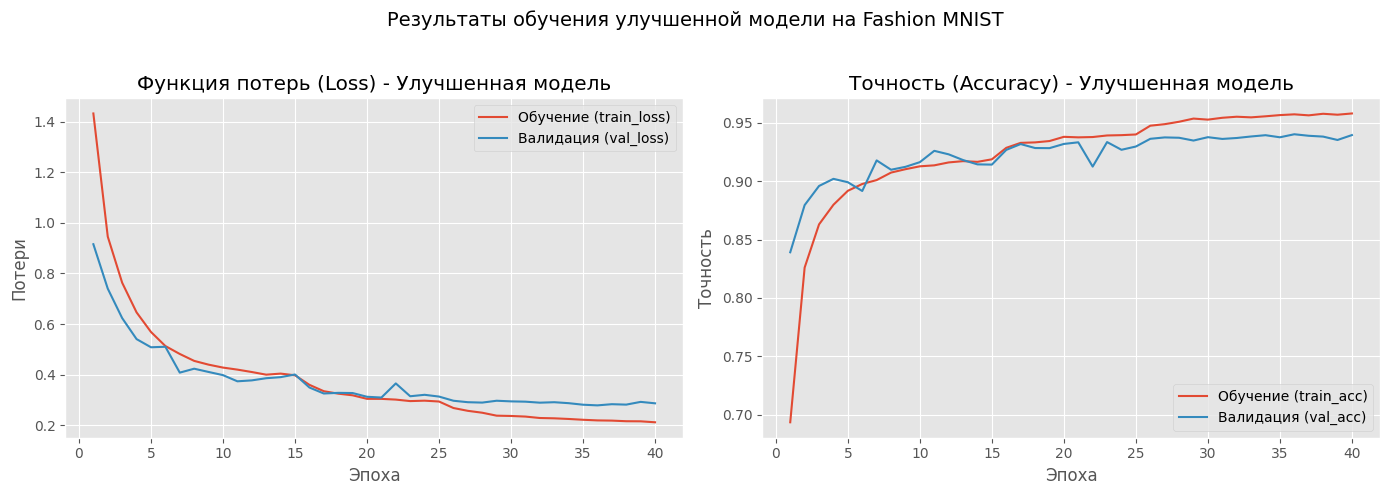

In [ ]:
model_task1_improved = tf.keras.models.load_model('best_model_task1_improved.keras')
test_loss, test_acc = model_task1_improved.evaluate(testX_cnn, testY_cat, verbose=0)
print(f"\nТочность на тестовых данных: {test_acc:.4f}")
print(f"Потери на тестовых данных: {test_loss:.4f}")

plt.style.use("ggplot")
epochs_range = np.arange(1, len(history_task1_improved.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history_task1_improved.history["loss"], label="Обучение (train_loss)")
ax1.plot(epochs_range, history_task1_improved.history["val_loss"], label="Валидация (val_loss)")
ax1.set_title("Функция потерь (Loss) - Улучшенная модель")
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Потери")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history_task1_improved.history["accuracy"], label="Обучение (train_acc)")
ax2.plot(epochs_range, history_task1_improved.history["val_accuracy"], label="Валидация (val_acc)")
ax2.set_title("Точность (Accuracy) - Улучшенная модель")
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Точность")
ax2.legend()
ax2.grid(True)

plt.suptitle("Результаты обучения улучшенной модели на Fashion MNIST", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



Загрузите минимум 5 своих изображений предметов одежды (по одному из разных классов).


Saving c4v1ddb85ahzoe5zmhovar77whvfknw1.jpg to c4v1ddb85ahzoe5zmhovar77whvfknw1 (1).jpg
Saving DSCF0097.jpg to DSCF0097 (2).jpg
Saving images.jpg to images (2).jpg

РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ


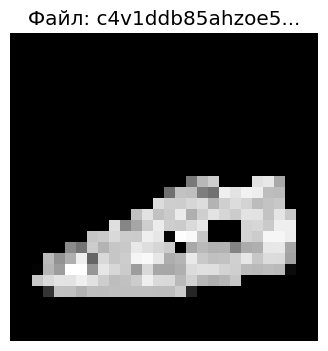

Файл: c4v1ddb85ahzoe5zmhovar77whvfknw1 (1).jpg
Предсказанный класс: Sandal
Уверенность: 99.90%
Топ-3 вероятности:
  Sandal: 99.90%
  Sneaker: 0.10%
  Bag: 0.00%
----------------------------------------


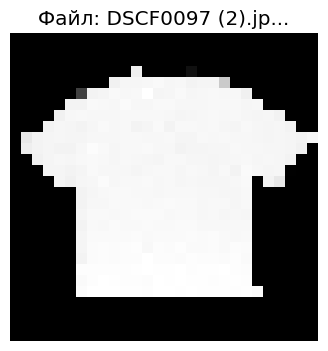

Файл: DSCF0097 (2).jpg
Предсказанный класс: T-shirt/top
Уверенность: 94.82%
Топ-3 вероятности:
  T-shirt/top: 94.82%
  Shirt: 5.13%
  Pullover: 0.05%
----------------------------------------


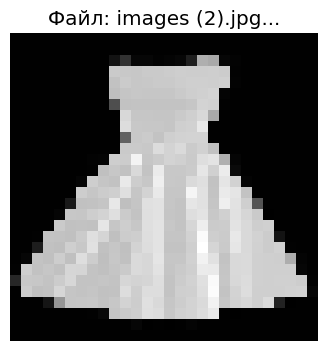

Файл: images (2).jpg
Предсказанный класс: Dress
Уверенность: 100.00%
Топ-3 вероятности:
  Dress: 100.00%
  Shirt: 0.00%
  Sandal: 0.00%
----------------------------------------


In [ ]:
def preprocess_user_image(image_path, img_size=28):
    """
    Загружает изображение, преобразует в оттенки серого,
    изменяет размер, инвертирует (если нужно) и нормализует.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (img_size, img_size))

    img = cv2.bitwise_not(img)
    img_norm = img.astype('float32') / 255.0
    img_reshaped = img_norm.reshape(1, img_size, img_size, 1)

    return img, img_reshaped

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Загрузите минимум 5 своих изображений предметов одежды (по одному из разных классов).")
uploaded = files.upload()

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ПРЕДСКАЗАНИЙ")
print("="*60)

model_task1 = tf.keras.models.load_model('best_model_task1.keras')

for i, filename in enumerate(uploaded.keys()):
    if i >= 10:
        break
    try:
        original_img, processed_img = preprocess_user_image(filename)

        predictions = model_task1.predict(processed_img, verbose=0)[0]
        predicted_class_index = np.argmax(predictions)
        confidence = np.max(predictions) * 100

        plt.figure(figsize=(4, 4))
        plt.imshow(original_img, cmap='gray')
        plt.title(f"Файл: {filename[:15]}...")
        plt.axis('off')
        plt.show()

        print(f"Файл: {filename}")
        print(f"Предсказанный класс: {class_names[predicted_class_index]}")
        print(f"Уверенность: {confidence:.2f}%")

        top_indices = np.argsort(predictions)[-3:][::-1]
        print("Топ-3 вероятности:")
        for idx in top_indices:
            print(f"  {class_names[idx]}: {predictions[idx]*100:.2f}%")
        print("-" * 40)

    except Exception as e:
        print(f"Ошибка при обработке файла {filename}: {e}")

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
# Ваш код

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [ ]:
# Ваш код

## 2.3. Сохраните полученные модели

In [ ]:
# Ваш код

## 2.4. Загрузите обученную модель из прошлой практической работы


In [ ]:
# Ваш код


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [ ]:
# Ваш код

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [ ]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

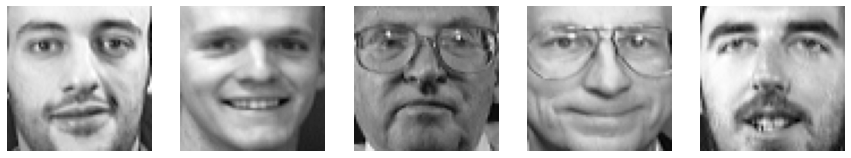

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [ ]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [ ]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

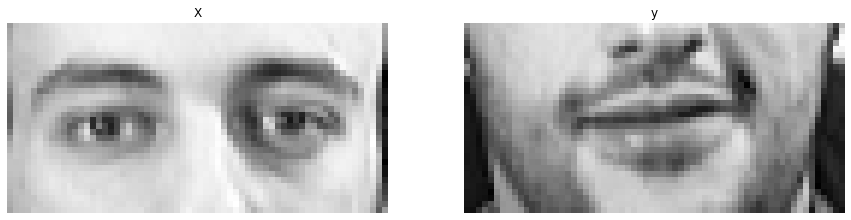

In [ ]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [ ]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [ ]:
# Ваш код здесь

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [ ]:
# Ваш код здесь

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [ ]:
# Ваш код здесь

## 3.5. Сделайте предсказания на тестовых данных

In [ ]:
# Ваш код здесь

## 3.6. Посчитайте метрику качества на тестовых данных

In [ ]:
# Ваш код здесь

from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_test_n)

## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [ ]:
# Ваш код здесь

Отрисуйте все предсказания.

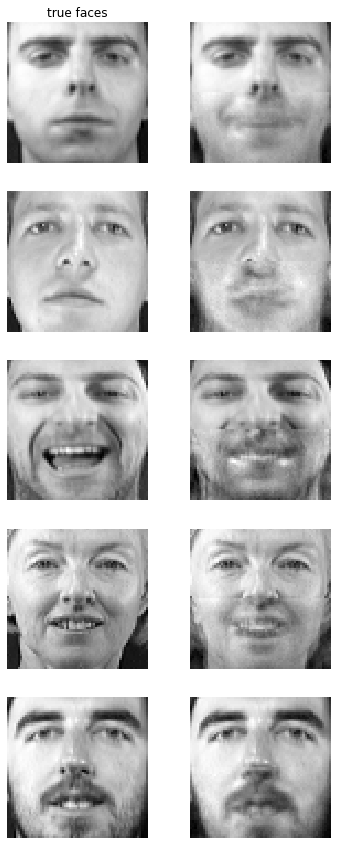

In [ ]:
# Пример кода:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

In [ ]:
# Ваш код здесь